# Interactive Gate-zone profiling

This notebook calls `GateImageProfiler` for the measurement mechanics—interactive white-light alignment, physical coordinates, rotation, grayscale conversion, and normalization. Plotting and pitch estimation remain here as analysis.

Workflow: select the white-light reference interactively, import the four ion frames with the same transform, inspect the calibrated images, then fit the axial pitch.

## 1. Enable interactive selection

The alignment uses native Matplotlib windows and waits for two clicks at each step. `%matplotlib qt` is available in this environment. If needed on another machine, `%matplotlib tk` is a suitable alternative.

In [20]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage, optimize

try:
    from Analysis.gate_image_profiler import GateFrameSet, GateImageProfiler
except ModuleNotFoundError:  # Also works when Jupyter starts inside Analysis/.
    from gate_image_profiler import GateFrameSet, GateImageProfiler


DATA_FOLDER = Path(
    "/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/"
    "My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/NANOLAB/"
    "Gen2_Ca_90/I/before_Optelligent/indiv"
)
WHITE_LIGHT_PATH = DATA_FOLDER / "white_light.bmp"
ION_FRAME_PATHS = {
    "ionM3": DATA_FOLDER / "ionM3.bmp",
    "ionM2": DATA_FOLDER / "ionM2.bmp",
    "ionM1": DATA_FOLDER / "ionM1.bmp",
    "ion0": DATA_FOLDER / "ion0.bmp",
}

missing = [str(path) for path in [WHITE_LIGHT_PATH, *ION_FRAME_PATHS.values()] if not path.is_file()]
if missing:
    raise FileNotFoundError("Missing image(s): " + ", ".join(missing))

profiler = GateImageProfiler(
    pixel_pitch_um=(5.3, 5.3),
    magnification=50.0,
    ion_relative_to_wg_lens_um=3.0,
    wg_lens_relative_to_trench_um=43.372,
    interpolation_order=0,  # MATLAB imrotate default: nearest neighbor
)


## 2. Align the white-light reference

Run the next cell and complete four two-click selections:

1. Select the **NW then SE** corners of a zoom region around a trench edge.
2. In the zoomed view, select **LEFT then RIGHT** points on that edge.
3. After rotation, select the **NW then SE** corners around the trench used as the origin.
4. In the zoomed view, select the **LEFT then RIGHT** trench edges. Their midpoint becomes `(0, 0)` in trench coordinates.

Close neither selection window manually; two clicks advance to the next step.

In [21]:
%matplotlib qt

# Reload the module so this kernel cannot retain an older class implementation.
import importlib
import matplotlib

gate_module = importlib.import_module(profiler.__class__.__module__)
gate_module = importlib.reload(gate_module)
profiler.__class__ = gate_module.GateImageProfiler
GateFrameSet = gate_module.GateFrameSet

print(f"Active Matplotlib backend: {matplotlib.get_backend()}")
print(f"Loaded profiler from: {gate_module.__file__}")

alignment = profiler.align_white_light(WHITE_LIGHT_PATH, brightness_offset=50.0)

print(f"Selected rotation: {alignment.angle_deg:.6f} degrees")
print(f"Trench center: {alignment.trench_center_px} px")
print(f"Sample spacing: {profiler.sample_spacing_um} um/px")
print("Angle points [px]:\n", alignment.rotation_points_px)
print("Trench-edge points [px]:\n", alignment.trench_edges_px)


Active Matplotlib backend: Qt5Agg
Loaded profiler from: /Users/yiyangzhi/GIT/integrated_trapped_ions/Analysis/gate_image_profiler.py
Selected rotation: 0.130812 degrees
Trench center: (640.4509286412513, 93.66517246194644) px
Sample spacing: (0.106, 0.106) um/px
Angle points [px]:
 [[ 154.69262673   93.58831169]
 [1127.06363636   95.80833682]]
Trench-edge points [px]:
 [[ 153.27517107   93.10391007]
 [1127.62668622   94.22643486]]


## 3. Import and normalize the ion frames

The same selected angle is applied to every frame. Each frame is divided by its own maximum so every peak reaches 1. This is useful for comparing position and shape, but intentionally discards relative peak-intensity information.

In [32]:
frames = profiler.import_frames(ION_FRAME_PATHS, normalization="per_frame")

print(f"Frame order: {frames.labels}")
print(f"Raw stack: {frames.raw.shape}, {frames.raw.dtype}")
print("Per-frame normalization maxima:")
for label, scale in zip(frames.labels, frames.normalization_scales):
    print(f"  {label:5s}: {scale:.3f}")
print(f"Normalized range: [{frames.normalized.min():.6f}, {frames.normalized.max():.6f}]")


Frame order: ('ionM3', 'ionM2', 'ionM1', 'ion0')
Raw stack: (1024, 1280, 4), float64
Per-frame normalization maxima:
  ionM3: 181.000
  ionM2: 181.000
  ionM1: 191.000
  ion0 : 187.000
Normalized range: [0.000000, 1.000000]


The interactive work is complete. Switch back to inline figures for persistent notebook output.

In [33]:
%matplotlib inline


## 4. Inspect rotated and physical coordinates

The upper row uses ordinary image pixels (`y` downward). The lower row uses Cartesian physical coordinates (`y` upward) and the Gate-class ion-centered radial axis.

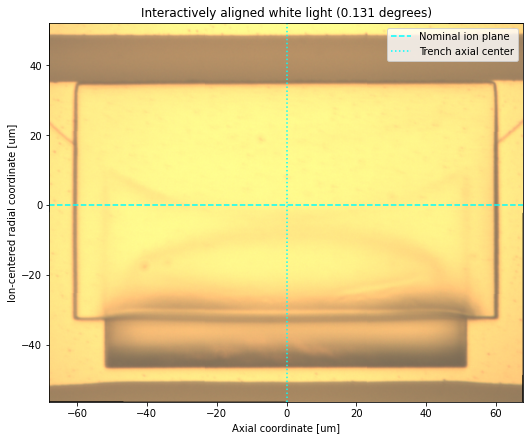

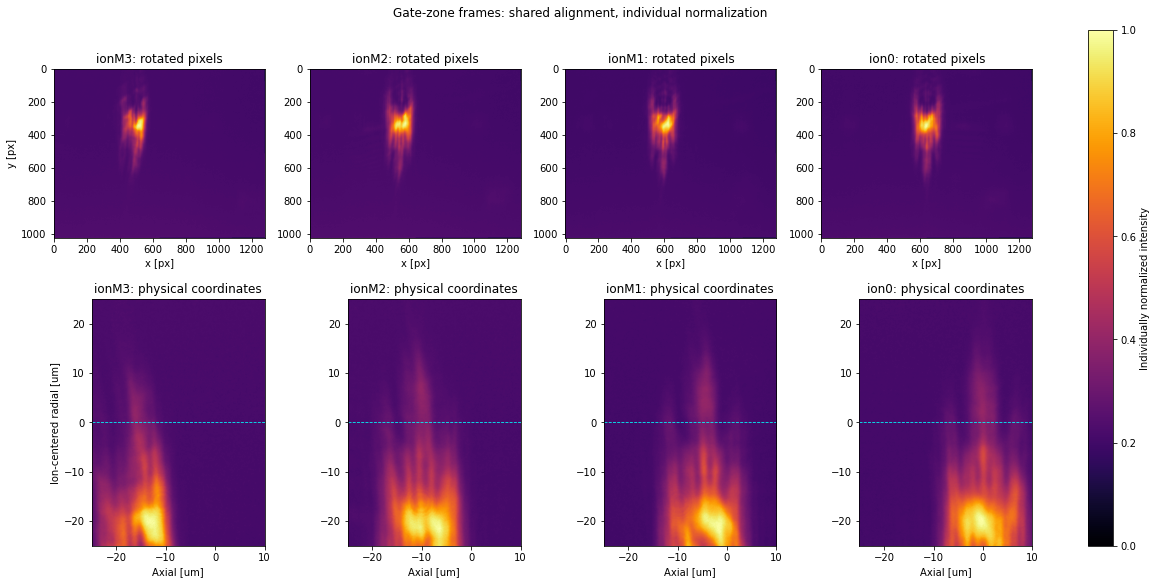

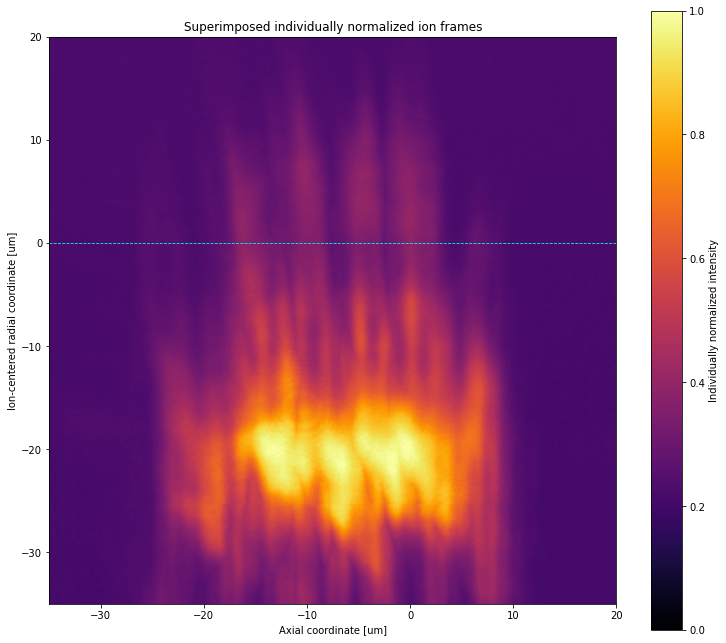

: 

In [ ]:
def physical_extent(x: np.ndarray, y: np.ndarray) -> Tuple[float, float, float, float]:
    """Convert pixel-center axes to the image-edge extent expected by imshow."""
    dx, dy = np.mean(np.diff(x)), np.mean(np.diff(y))
    return x[0] - dx / 2, x[-1] + dx / 2, y[0] - dy / 2, y[-1] + dy / 2


# Check the selected origin on the aligned white-light image.
fig, axis = plt.subplots(figsize=(8, 6), constrained_layout=True)
axis.imshow(
    alignment.image,
    origin="lower",
    extent=physical_extent(alignment.x_um, alignment.y_ion_um),
    aspect="equal",
)
axis.axhline(0, color="cyan", linestyle="--", label="Nominal ion plane")
axis.axvline(0, color="cyan", linestyle=":", label="Trench axial center")
axis.set(
    title=f"Interactively aligned white light ({alignment.angle_deg:.3f} degrees)",
    xlabel="Axial coordinate [um]",
    ylabel="Ion-centered radial coordinate [um]",
)
axis.legend()
plt.show()


# Compare rotated pixels with the physical-coordinate view.
fig, axes = plt.subplots(2, len(frames.labels), figsize=(16, 8), constrained_layout=True)
extent = physical_extent(frames.x_um, frames.y_ion_um)
for index, label in enumerate(frames.labels):
    axes[0, index].imshow(
        frames.normalized[..., index], origin="upper", cmap="inferno", vmin=0, vmax=1
    )
    axes[0, index].set(title=f"{label}: rotated pixels", xlabel="x [px]")
    if index == 0:
        axes[0, index].set_ylabel("y [px]")

    image_artist = axes[1, index].imshow(
        frames.normalized[..., index],
        origin="lower",
        extent=extent,
        cmap="inferno",
        vmin=0,
        vmax=1,
        aspect="equal",
    )
    axes[1, index].axhline(0, color="cyan", linestyle="--", linewidth=0.8)
    axes[1, index].set(
        title=f"{label}: physical coordinates",
        xlabel="Axial [um]",
        xlim=(-25, 10),
        ylim=(-25, 25),
    )
    if index == 0:
        axes[1, index].set_ylabel("Ion-centered radial [um]")

fig.colorbar(image_artist, ax=axes.ravel().tolist(), label="Individually normalized intensity")
fig.suptitle("Gate-zone frames: shared alignment, individual normalization")
plt.show()


# Maximum-intensity superposition: every frame is already normalized to 1,
# and all frames use the same colormap and physical coordinate system.
superimposed = np.max(frames.normalized, axis=2)

fig, axis = plt.subplots(figsize=(10, 9), constrained_layout=True)
superimposed_artist = axis.imshow(
    superimposed,
    origin="lower",
    extent=extent,
    cmap="inferno",
    vmin=0,
    vmax=1,
    aspect="equal",
)
axis.axhline(0, color="cyan", linestyle="--", linewidth=0.8)
axis.set(
    title="Superimposed individually normalized ion frames",
    xlabel="Axial coordinate [um]",
    ylabel="Ion-centered radial coordinate [um]",
    xlim=(-35, 20),
    ylim=(-35, 20),
)
fig.colorbar(superimposed_artist, ax=axis, label="Individually normalized intensity")
plt.show()


## 5. Estimate the axial pitch

This analysis stays in the notebook. It averages a selected radial region into an axial profile and fits a Gaussian plus linear background. The reported fit error is numerical precision only; point selection, magnification, ROI, and model choice remain systematic uncertainties.

In [29]:
@dataclass(frozen=True)
class PitchEstimate:
    labels: Tuple[str, ...]
    ion_indices: np.ndarray
    x_um: np.ndarray
    profiles: np.ndarray
    fitted_profiles: np.ndarray
    centers_um: np.ndarray
    center_fit_stderr_um: np.ndarray
    fit_r_squared: np.ndarray
    adjacent_pitch_um: np.ndarray
    regression_pitch_um: float
    regression_r_squared: float


def gaussian_with_background(x, amplitude, center, sigma, offset, slope):
    return offset + slope * x + amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)


def estimate_pitch(
    data: GateFrameSet,
    ion_indices: Sequence[float],
    *,
    x_window_um: Tuple[float, float] = (-35, 35),
    y_window_um: Tuple[float, float] = (-25, 25),
) -> PitchEstimate:
    indices = np.asarray(ion_indices, dtype=float)
    if indices.shape != (len(data.labels),) or np.any(np.diff(indices) <= 0):
        raise ValueError("Provide one strictly increasing ion index per frame")

    x_low, x_high = sorted(x_window_um)
    y_low, y_high = sorted(y_window_um)
    x_mask = (data.x_um >= x_low) & (data.x_um <= x_high)
    y_mask = (data.y_ion_um >= y_low) & (data.y_ion_um <= y_high)
    if x_mask.sum() < 20 or y_mask.sum() < 2:
        raise ValueError("The selected analysis ROI is too small")

    x = data.x_um[x_mask]
    smooth_pixels = max(1.0, 0.5 / abs(np.mean(np.diff(x))))
    profiles, fitted, centers, errors, fit_quality = [], [], [], [], []

    for frame_index, label in enumerate(data.labels):
        profile = data.normalized[y_mask, :, frame_index][:, x_mask].mean(axis=0)
        smoothed = ndimage.gaussian_filter1d(profile, smooth_pixels)
        center_guess = x[np.argmax(smoothed)]
        baseline = np.percentile(profile, 20)
        initial = [max(profile.max() - baseline, 1e-12), center_guess, 4.0, baseline, 0.0]
        bounds = (
            [0.0, x_low, 0.2, -np.inf, -np.inf],
            [np.inf, x_high, 20.0, np.inf, np.inf],
        )
        try:
            parameters, covariance = optimize.curve_fit(
                gaussian_with_background, x, profile, p0=initial, bounds=bounds, maxfev=50000
            )
        except (RuntimeError, ValueError) as error:
            raise RuntimeError(f"Could not fit {label!r}") from error

        model = gaussian_with_background(x, *parameters)
        residual = np.sum((profile - model) ** 2)
        total = np.sum((profile - profile.mean()) ** 2)
        profiles.append(profile)
        fitted.append(model)
        centers.append(parameters[1])
        errors.append(np.sqrt(covariance[1, 1]))
        fit_quality.append(1 - residual / total)

    centers = np.asarray(centers)
    regression_pitch, intercept = np.polyfit(indices, centers, 1)
    predicted = regression_pitch * indices + intercept
    regression_r_squared = 1 - np.sum((centers - predicted) ** 2) / np.sum(
        (centers - centers.mean()) ** 2
    )
    return PitchEstimate(
        labels=data.labels,
        ion_indices=indices,
        x_um=x,
        profiles=np.asarray(profiles),
        fitted_profiles=np.asarray(fitted),
        centers_um=centers,
        center_fit_stderr_um=np.asarray(errors),
        fit_r_squared=np.asarray(fit_quality),
        adjacent_pitch_um=np.diff(centers) / np.diff(indices),
        regression_pitch_um=float(regression_pitch),
        regression_r_squared=float(regression_r_squared),
    )


Fitted axial centers:
  ionM3: -14.4381 um  (fit SE=0.0510, R^2=0.9376)
  ionM2:  -9.6280 um  (fit SE=0.0390, R^2=0.9753)
  ionM1:  -4.2543 um  (fit SE=0.0387, R^2=0.9746)
  ion0 :   0.1231 um  (fit SE=0.0381, R^2=0.9761)
Adjacent separations [um]: [4.8101 5.3737 4.3774]
Mean adjacent separation: 4.8537 um
Regression pitch: 4.9057 um/index (R^2=0.99860)


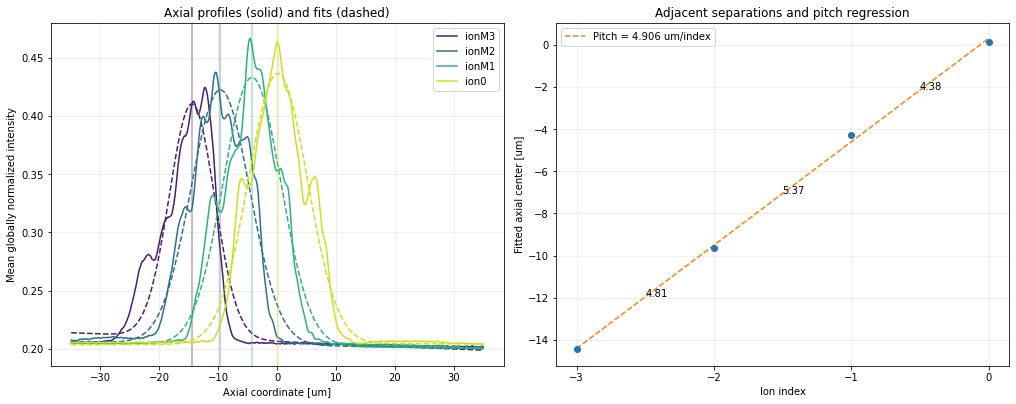

In [30]:
pitch = estimate_pitch(frames, ion_indices=(-3, -2, -1, 0))

print("Fitted axial centers:")
for label, center, error, r_squared in zip(
    pitch.labels, pitch.centers_um, pitch.center_fit_stderr_um, pitch.fit_r_squared
):
    print(f"  {label:5s}: {center:8.4f} um  (fit SE={error:.4f}, R^2={r_squared:.4f})")
print("Adjacent separations [um]:", np.round(pitch.adjacent_pitch_um, 4))
print(f"Mean adjacent separation: {pitch.adjacent_pitch_um.mean():.4f} um")
print(
    f"Regression pitch: {pitch.regression_pitch_um:.4f} um/index "
    f"(R^2={pitch.regression_r_squared:.5f})"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(pitch.labels)))
for index, (label, color) in enumerate(zip(pitch.labels, colors)):
    axes[0].plot(pitch.x_um, pitch.profiles[index], color=color, label=label)
    axes[0].plot(pitch.x_um, pitch.fitted_profiles[index], color=color, linestyle="--")
    axes[0].axvline(pitch.centers_um[index], color=color, alpha=0.4)
axes[0].set(
    title="Axial profiles (solid) and fits (dashed)",
    xlabel="Axial coordinate [um]",
    ylabel="Mean globally normalized intensity",
)
axes[0].grid(alpha=0.25)
axes[0].legend()

line = np.polyval(np.polyfit(pitch.ion_indices, pitch.centers_um, 1), pitch.ion_indices)
axes[1].errorbar(
    pitch.ion_indices, pitch.centers_um, yerr=pitch.center_fit_stderr_um, fmt="o", capsize=3
)
axes[1].plot(
    pitch.ion_indices, line, "--", label=f"Pitch = {pitch.regression_pitch_um:.3f} um/index"
)
for left, separation in zip(pitch.ion_indices[:-1], pitch.adjacent_pitch_um):
    axes[1].text(left + 0.5, np.interp(left + 0.5, pitch.ion_indices, line), f"{separation:.2f}")
axes[1].set(
    title="Adjacent separations and pitch regression",
    xlabel="Ion index",
    ylabel="Fitted axial center [um]",
)
axes[1].set_xticks(pitch.ion_indices)
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.show()


## Class/notebook boundary

`GateImageProfiler` contains only reusable measurement operations. The notebook owns visualization choices, ROIs, fit models, and interpretation. This keeps the class concise and lets the analysis evolve without changing the import pipeline.